In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import os
import argparse
import keras
import tensorflow as tf
from keras.models import Sequential, load_model, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization,Rescaling, Activation
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras.utils import image_dataset_from_directory,img_to_array, array_to_img, save_img
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image


In [2]:
path = "C:/Users/Dell/PycharmProjects/Deep Learning/cat_dog"
new_dir = ['cat', 'dog']

for i in new_dir:
    os.makedirs(os.path.join(path, i), exist_ok=True)

for element in os.listdir(path):
    full_path = os.path.join(path, element)
    
    if os.path.isfile(full_path):  # ← only process files, skip folders
        if element.startswith("dog"):
            os.rename(full_path, os.path.join(path, "dog", element))
        elif element.startswith("cat"):
            os.rename(full_path, os.path.join(path, "cat", element))

In [3]:
train_data = image_dataset_from_directory(
   "C:/Users/Dell/PycharmProjects/Deep Learning/cat_dog",
    labels="inferred",
    image_size=(128, 128),
    batch_size=32,
    color_mode="rgb",
    validation_split=0.2,
    subset="training",
    shuffle=True,
    seed=42,     
    format="tf"
)

val_data = image_dataset_from_directory(
   "C:/Users/Dell/PycharmProjects/Deep Learning/cat_dog",
    labels="inferred",
    image_size=(128, 128),
    batch_size=32,
    color_mode="rgb",
    validation_split=0.2,
    subset="validation",
    shuffle=True,
    seed=42,     
    format="tf"
)


Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [4]:
print("Number of training batches:", len(train_data))
print("Number of validation batches:", len(val_data))
#for images, labels in train_data.take(1):
#     print("Batch of images shape:", images.shape)
#     print("Batch of labels shape:", labels.shape)
#     print("Data", images)



Number of training batches: 625
Number of validation batches: 157


In [5]:
# scaeler = tf.keras.layers.Rescaling(1./255)
# train_data = train_data.map(lambda x, y: (scaeler(x), y))
# # for data, _ in train_data.take(1):
# #     print("Scaled batch of images shape:", data)

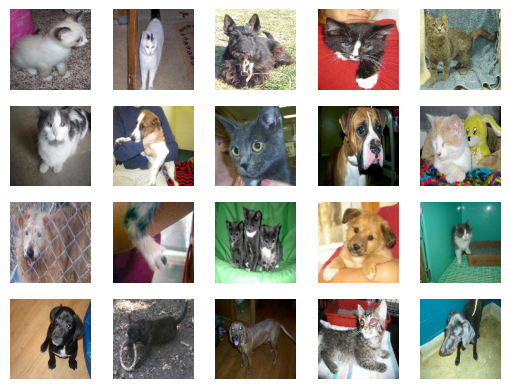

In [6]:
images, labels = next(iter(train_data))
for idx, i in enumerate(images[:20]):
    for j in labels[:20]:
        i = img_to_array(i)
        plt.subplot(4, 5, idx+1)
        plt.xlabel(j)
        plt.imshow(i.astype("uint8"))
        plt.axis("off") 

In [7]:
data_augmentation = Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

In [8]:
model = Sequential()
model.add(Rescaling(1./255, input_shape=(128, 128, 3)))
model.add(data_augmentation)
model.add(Conv2D(16, kernel_size=(3, 3), activation='relu', name='conv2d_1'))
model.add(MaxPooling2D(pool_size=(2, 2), name='max_pooling_1'))

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', name='conv2d_2'))
model.add(MaxPooling2D(pool_size=(2, 2), name='max_pooling_2'))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv2d_3'))
model.add(MaxPooling2D(pool_size=(2, 2), name='max_pooling_3'))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', name='conv2d_4'))
model.add(MaxPooling2D(pool_size=(2, 2), name='max_pooling_4'))

model.add(Flatten(name='flatten'))
model.add(Dense(64, kernel_regularizer=keras.regularizers.l2(0.001), activation='relu', name='dense_1'))
model.add(Dense(32, activation='relu', name='dense_2'))
model.add(Dense(16,  activation='relu', name='Next_output_layer'))
model.add(Dense(1, activation='sigmoid', name='output_layer'))

model.summary()

c:\Users\Dell\PycharmProjects\Azure ML\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_1 (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_2 (MaxPooling2D)    │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_3 (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_4 (MaxPooling2D)    │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Next_output_layer (Dense)       │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,041 (1.51 MB)

 Trainable params: 395,041 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_data, epochs=40, validation_data= val_data, )

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 318ms/step - accuracy: 0.6095 - loss: 0.6955 - val_accuracy: 0.7080 - val_loss: 0.5978
Epoch 2/40
 84/625 ━━━━━━━━━━━━━━━━━━━━ 15:00 2s/step - accuracy: 0.6838 - loss: 0.6236

### TESTING AND EVALUATION

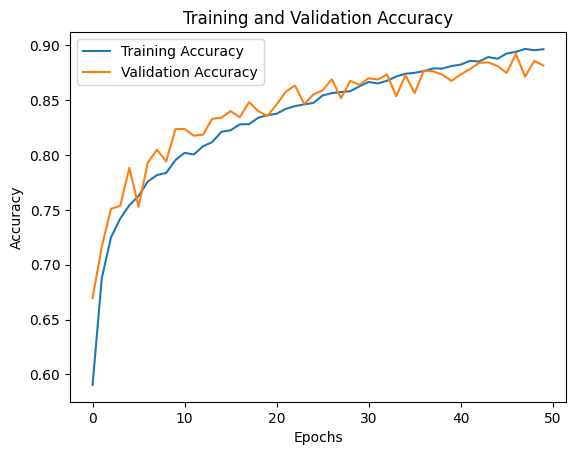

In [ ]:
plt.plot(model.history['accuracy'], label='Training Accuracy')
plt.plot(model.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()    

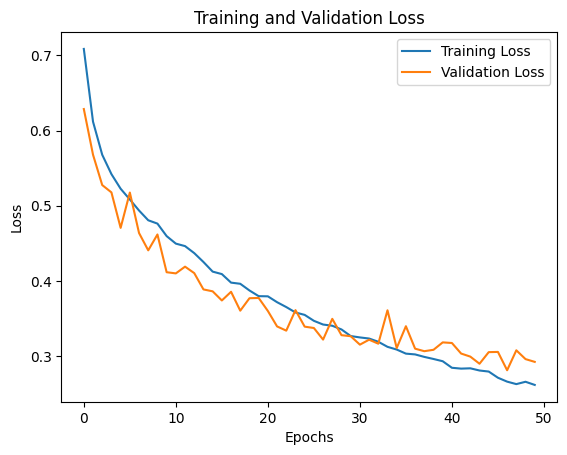

In [ ]:
plt.plot(model.history['loss'], label='Training Loss')
plt.plot(model.history["val_loss"], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()    

In [ ]:
model.save("cat_dog_classifier_L.keras")

AttributeError: 'History' object has no attribute 'save'

In [ ]:
def get_data(path):
    image_data_list = []
    label = []
    for i in os.listdir(path):
        if i.endswith('jpg') or i.endswith('png'):
            elements = os.path.join(path, i)
            img = cv2.imread(elements)
            img = cv2.resize(img, (128,128))
            image_data_list.append(img)
            if i.startswith('dog'):
                lab = 1
            else:
                lab = 0
            label.append(lab)
    label = np.array(label)
    image_data_list = np.array(image_data_list)
    plt.imshow(image_data_list[50])
    plt.show() 
    image = image_data_list.shape[0]
    print(image)
    return image_data_list, label

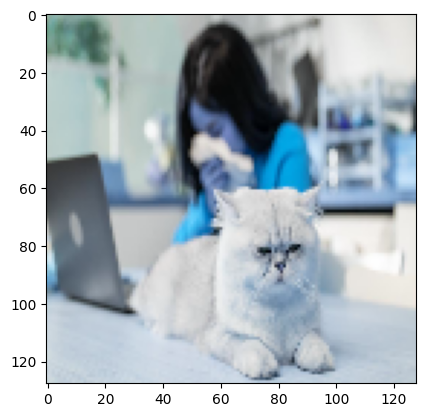

557


In [ ]:
import cv2
path = 'C:/Users/Dell/Desktop/train/Train'
image_data_list, label = get_data(path)